# CTEPH AGP3K v6 — CRAM information summary

Build a summary table for samples with `Flag_JHRPv6 == True`.

**Steps**
1. From `info/cteph_agp3k.v6.20260507.xlsx`, take the `Flag_JHRPv6 == True` rows and record, keyed by `ID_JHRPv6`:
   `Observed_Depth`, `Target_Depth`, `WGS_Platform`, `Project`, `Outcome`.
2. Locate each sample's CRAM under `/LARGE1/gr10478/pub/WGS/cram` or
   `/LARGE0/gr10478/pub/WGS/cram4temporary` (file may sit up to 2 sub-directory levels deep),
   named `<ID_JHRPv6>.cram`, and write its absolute path into the `Cram_Path` column.
3. Stat each located CRAM and record its size in `Cram_Size_Bytes` and `Cram_Size_GB`.

In [1]:
import os
import glob
import pandas as pd

# --- Configuration ---
INFO_XLSX = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/info/cteph_agp3k.v6.20260507.xlsx"

CRAM_ROOTS = [
    "/LARGE1/gr10478/pub/WGS/cram",
    "/LARGE0/gr10478/pub/WGS/cram4temporary",
]

# Columns copied from the info sheet into the summary
META_COLS = ["Observed_Depth", "Target_Depth", "WGS_Platform", "Project", "Outcome"]

# Output goes next to this notebook
OUT_DIR = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tmp/cram.v6"
OUT_XLSX = os.path.join(OUT_DIR, "cram.v6.summary.xlsx")
OUT_CSV = os.path.join(OUT_DIR, "cram.v6.summary.csv")

In [2]:
# --- Step 1: load info sheet and keep Flag_JHRPv6 == True samples ---
info = pd.read_excel(INFO_XLSX)
print("info sheet:", info.shape)

flagged = info.loc[info["Flag_JHRPv6"] == True].copy()
print("Flag_JHRPv6 == True:", len(flagged))

# Build the summary keyed on ID_JHRPv6
summary = flagged[["ID_JHRPv6"] + META_COLS].reset_index(drop=True)

# Sanity check: ID_JHRPv6 should be unique and non-null
assert summary["ID_JHRPv6"].notna().all(), "ID_JHRPv6 contains NaN among flagged rows"
assert summary["ID_JHRPv6"].is_unique, "ID_JHRPv6 is not unique among flagged rows"
summary["ID_JHRPv6"] = summary["ID_JHRPv6"].astype(str)

summary.head()

info sheet: (3655, 37)
Flag_JHRPv6 == True: 3592


,ID_JHRPv6,Observed_Depth,Target_Depth,WGS_Platform,Project,Outcome
0,PHOM0001,29.4216,30x,DNBSeq-T7 30x,Old PH,PH
1,PHOM0003,31.5706,30x,DNBSeq-T7 30x,Old PH,PH
2,PHOM0005,27.9373,30x,DNBSeq-T7 30x,Old PH,PH
3,PHOM0010,26.9826,30x,DNBSeq-T7 30x,Old PH,PH
4,PHOM0012,26.5871,30x,DNBSeq-T7 30x,Old PH,PH


In [3]:
# --- Step 2a: index every CRAM under the two roots, up to 2 sub-directory levels deep ---
# Depth patterns (relative to each root):
#   <root>/<ID>.cram            (0 sub-dirs)
#   <root>/*/<ID>.cram          (1 sub-dir)
#   <root>/*/*/<ID>.cram        (2 sub-dirs)
DEPTH_PATTERNS = ["*.cram", "*/*.cram", "*/*/*.cram"]

cram_index = {}        # basename (no .cram)  ->  absolute path
duplicates = {}        # basename            ->  [all paths] when >1 hit

for root in CRAM_ROOTS:
    for pat in DEPTH_PATTERNS:
        for path in glob.glob(os.path.join(root, pat)):
            key = os.path.basename(path)[:-len(".cram")]
            if key in cram_index and os.path.abspath(path) != cram_index[key]:
                duplicates.setdefault(key, [cram_index[key]]).append(os.path.abspath(path))
            else:
                cram_index[key] = os.path.abspath(path)

print("indexed CRAM files:", len(cram_index))
print("basenames with >1 path (kept first seen):", len(duplicates))
if duplicates:
    for k in list(duplicates)[:5]:
        print("  dup:", k, duplicates[k])

indexed CRAM files: 10558
basenames with >1 path (kept first seen): 0


In [4]:
# --- Step 2b: map each ID_JHRPv6 to its CRAM path ---
summary["Cram_Path"] = summary["ID_JHRPv6"].map(cram_index)

found = summary["Cram_Path"].notna()
print(f"CRAM found : {found.sum()} / {len(summary)}")
print(f"CRAM missing: {(~found).sum()}")

# Which roots did the found CRAMs come from?
def _root_of(p):
    for r in CRAM_ROOTS:
        if isinstance(p, str) and p.startswith(r + os.sep):
            return r
    return None

print("\nfound by root:")
print(summary.loc[found, "Cram_Path"].map(_root_of).value_counts())

# Breakdown of the missing ones by Project
print("\nmissing by Project:")
print(summary.loc[~found, "Project"].value_counts())

CRAM found : 3481 / 3592
CRAM missing: 111

found by root:
Cram_Path
/LARGE1/gr10478/pub/WGS/cram    3481
Name: count, dtype: int64

missing by Project:
Project
Control_BBJ    111
Name: count, dtype: int64


In [5]:
# --- Step 3: record the size of each located CRAM ---
def _size_of(p):
    if not isinstance(p, str):
        return pd.NA
    try:
        return os.path.getsize(p)
    except OSError:
        # broken symlink or unreadable file
        return pd.NA

summary["Cram_Size_Bytes"] = summary["Cram_Path"].map(_size_of).astype("Int64")
summary["Cram_Size_GB"] = (summary["Cram_Size_Bytes"] / 1024**3).round(2)

sized = summary["Cram_Size_Bytes"].notna()
print(f"sizes read : {sized.sum()} / {found.sum()} located CRAMs")
print(f"stat failed: {(found & ~sized).sum()}")
print(f"total size : {summary['Cram_Size_Bytes'].sum() / 1024**4:.2f} TiB")

print("\nCram_Size_GB by Target_Depth:")
print(summary.loc[sized].groupby("Target_Depth")["Cram_Size_GB"].describe()[["count", "mean", "min", "max"]])

sizes read : 3481 / 3481 located CRAMs
stat failed: 0
total size : 62.37 TiB

Cram_Size_GB by Target_Depth:
               count       mean    min    max
Target_Depth                                 
15x           3055.0  17.505368  11.33  50.25
30x            426.0  24.389648  14.99  73.45


In [6]:
# --- Step 4: add found flag, finalize column order, preview, and save ---
# Cram_Found marks whether the CRAM was located; Cram_Path/Cram_Size_* stay empty when not found.
summary["Cram_Found"] = summary["Cram_Path"].notna()

summary = summary[["ID_JHRPv6"] + META_COLS + ["Cram_Path", "Cram_Found", "Cram_Size_Bytes", "Cram_Size_GB"]]

print("final summary:", summary.shape)
print("Cram_Found value counts:")
print(summary["Cram_Found"].value_counts())
display(summary.head(10))

summary.to_csv(OUT_CSV, index=False)
summary.to_excel(OUT_XLSX, index=False)
print("wrote:", OUT_CSV)
print("wrote:", OUT_XLSX)

final summary: (3592, 10)
Cram_Found value counts:
Cram_Found
True     3481
False     111
Name: count, dtype: int64


,ID_JHRPv6,Observed_Depth,Target_Depth,WGS_Platform,Project,Outcome,Cram_Path,Cram_Found,Cram_Size_Bytes,Cram_Size_GB
0,PHOM0001,29.4216,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,23300949398,21.7
1,PHOM0003,31.5706,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,24107592429,22.45
2,PHOM0005,27.9373,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,21495495581,20.02
3,PHOM0010,26.9826,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,20409633943,19.01
4,PHOM0012,26.5871,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,20176019778,18.79
5,PHOM0016,26.0016,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,20174438409,18.79
6,PHOM0020,27.3760,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,21456210740,19.98
7,PHOM0021,28.4302,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,21694211351,20.2
8,PHOM0026,28.0418,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,21740811132,20.25
9,PHOM0027,29.0255,30x,DNBSeq-T7 30x,Old PH,PH,/LARGE1/gr10478/pub/WGS/cram/Pulmonary_Hyperte...,True,22062828859,20.55


wrote: /LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tmp/cram.v6/cram.v6.summary.csv
wrote: /LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tmp/cram.v6/cram.v6.summary.xlsx


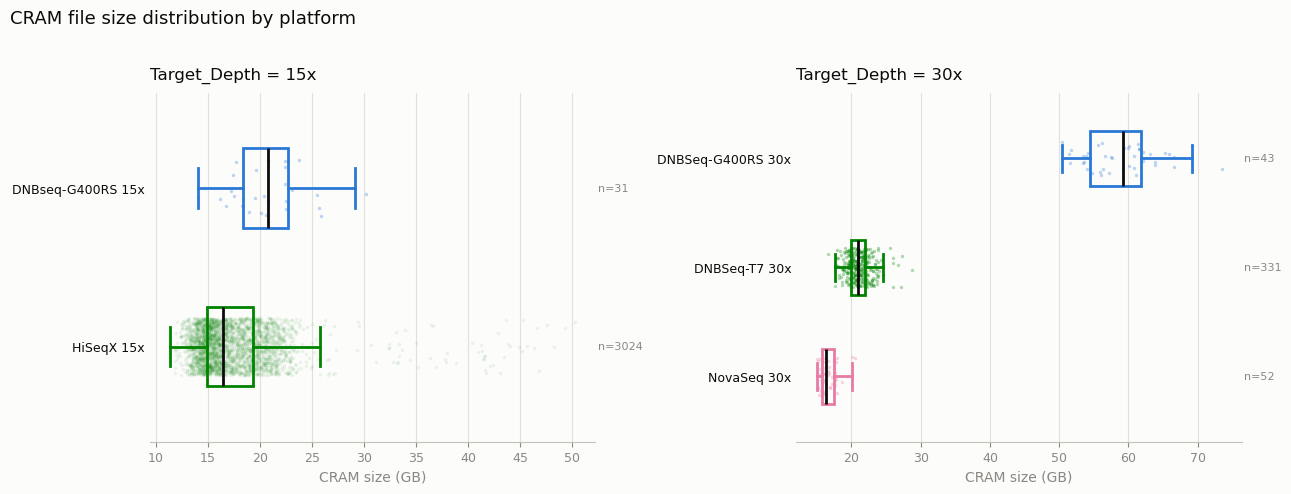


Cram_Size_GB by Target_Depth x WGS_Platform:
                                count  median   mean   std    min    max
Target_Depth WGS_Platform                                               
15x          DNBseq-G400RS 15x     31   20.76  21.11  3.68  14.05   30.2
             HiSeqX 15x          3024   16.44  17.47  4.15  11.33  50.25
30x          DNBSeq-G400RS 30x     43   59.27  58.91   5.2  50.38  73.45
             DNBSeq-T7 30x        331   20.95  21.12  1.63  16.64  28.79
             NovaSeq 30x           52   16.38  16.69  1.26  14.99  20.59


In [7]:
# --- Step 5: CRAM size distribution, one panel per Target_Depth, split by WGS_Platform ---
# Box + jittered raw points rather than overlapping histograms: within a panel the
# per-platform spread ranges from std 0.36 GB (NovaSeq 30x) to 5.2 GB (DNBSeq-G400RS 30x)
# and n from 26 to 3024, so density curves would be one spike plus flat smears.
import numpy as np
import matplotlib.pyplot as plt

# Categorical slots in fixed order; each box is also direct-labelled on the y-axis,
# so identity never rests on colour alone.
SERIES_COLORS = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]
SURFACE, MUTED, GRID, INK, AXIS = "#fcfcfb", "#898781", "#e1e0d9", "#0b0b0b", "#c3c2b7"

plot_df = summary.loc[summary["Cram_Size_GB"].notna()]
DEPTHS = ["15x", "30x"]
rng = np.random.default_rng(0)  # fixed seed: jitter is decoration, not data

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), facecolor=SURFACE)

for ax, depth in zip(axes, DEPTHS):
    panel = plot_df.loc[plot_df["Target_Depth"] == depth]
    # Sort by name, not by n: colour follows the platform, not its rank
    plats = sorted(panel["WGS_Platform"].unique())

    for i, plat in enumerate(plats):
        vals = panel.loc[panel["WGS_Platform"] == plat, "Cram_Size_GB"].to_numpy(dtype=float)
        color = SERIES_COLORS[i]
        y = i + 1

        # Raw points first, so the box reads on top of them. Alpha falls with n so a
        # 3000-point cloud doesn't swamp its own box outline (same hue).
        alpha = min(0.30, 20.0 / len(vals) ** 0.7)
        ax.scatter(vals, y + rng.uniform(-0.18, 0.18, len(vals)),
                   s=6, color=color, alpha=alpha, linewidths=0, zorder=2)
        ax.boxplot([vals], positions=[y], vert=False, widths=0.5, showfliers=False,
                   patch_artist=True, zorder=3,
                   boxprops=dict(facecolor="none", color=color, linewidth=2),
                   whiskerprops=dict(color=color, linewidth=2),
                   capprops=dict(color=color, linewidth=2),
                   medianprops=dict(color=INK, linewidth=2))
        # n sits with its row, so the reader never counts points
        ax.text(1.005, y, f"n={len(vals)}", transform=ax.get_yaxis_transform(),
                va="center", ha="left", color=MUTED, fontsize=8)

    ax.set_yticks(range(1, len(plats) + 1))
    ax.set_yticklabels(plats)
    ax.set_ylim(0.4, len(plats) + 0.6)
    ax.invert_yaxis()  # alphabetical reads top-down
    ax.set_facecolor(SURFACE)
    ax.set_title(f"Target_Depth = {depth}", color=INK, fontsize=12, loc="left", pad=10)
    ax.set_xlabel("CRAM size (GB)", color=MUTED, fontsize=10)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.tick_params(axis="y", length=0, labelcolor=INK)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)

# Independent x per panel: 15x and 30x differ in magnitude, and a shared scale
# would compress the 15x panel against the 30x tail.
fig.suptitle("CRAM file size distribution by platform", color=INK, fontsize=13,
             x=0.01, ha="left", y=1.02)
fig.tight_layout()
plt.show()

# Table view: the numbers behind the boxes
print("\nCram_Size_GB by Target_Depth x WGS_Platform:")
print(plot_df.groupby(["Target_Depth", "WGS_Platform"])["Cram_Size_GB"]
      .agg(["count", "median", "mean", "std", "min", "max"]).round(2).to_string())